<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
از دید ناحیه
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین قصد داریم تا با استفاده از قطعه‌بندی مبتنی بر ناحیه، قطعه‌بندی را انجام دهیم.
</font>
</p>

In [68]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را بصورت خاکستری بخوانید.
<br>
brain.webp
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
همچنین در صورتیکه نیاز به اعمال پیش‌پردازش میباشد آنرا نیز در این مرحله انجام دهید.
</p>


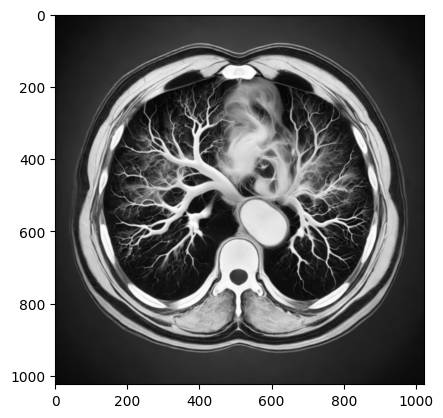

In [69]:
gray = cv2.imread('Data/brain.webp', cv2.IMREAD_GRAYSCALE)
blurred = cv2.GaussianBlur(gray,(5, 5),0)

plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: پیاده‌سازی گسترش ناحیه
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای قطعه‌بندی ما از رویکرد گسترش‌ناحیه یا Region Growing استفاده می‌کنیم. شما باید آنرا پیاده‌سازی کنید.
    <br>
    پس از پیاده‌سازی و انجام قطعه‌بندی، باید تصویر قطعه‌بندی شده را ذخیره کنید. توجه کنید که پیش‌زمینه حتما سیاه باشد و پس‌زمینه حتما سفید باشد. تصویر را به نام زیر ذخیره کنید:
    <br>
    region_segment.jpg
</font>
</p>

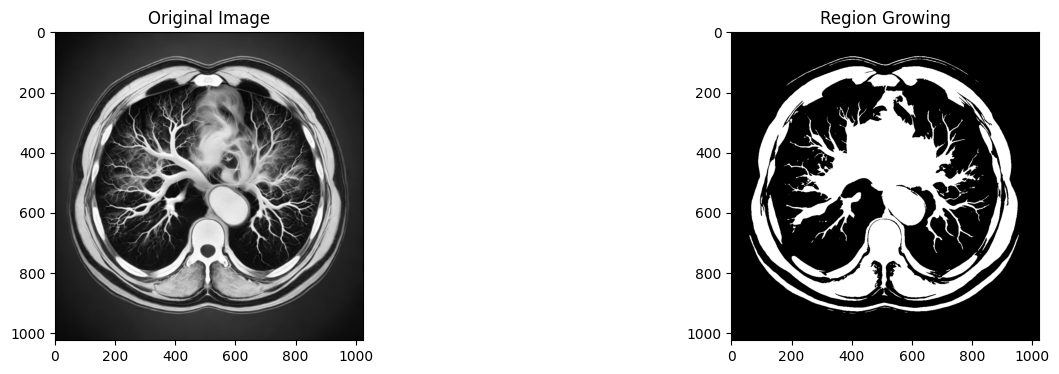

In [70]:
def region_growing(img, seed, threshold=20):
    h, w = img.shape
    mask = np.ones_like(img, dtype=np.uint8) * 255
    seed_value = img[seed]
    stack = [seed]

    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    while stack:
        x, y = stack.pop()
        if mask[y, x] == 255 and abs(int(img[y, x]) - int(seed_value)) < threshold:
            mask[y, x] = 0
            for dx, dy in neighbors:
                nx, ny = x + dx, y + dy
                if 0 <= nx < w and 0 <= ny < h:
                    stack.append((nx, ny))
    return mask



seed_point = (100, 100)
segment_image = region_growing(blurred, seed_point, threshold=100)


fig, ax = plt.subplots(1, 2, figsize=(16, 4))
ax[0].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB), cmap='gray')
ax[0].set_title("Original Image")
ax[1].imshow(cv2.cvtColor(segment_image, cv2.COLOR_BGR2RGB), cmap='gray')
ax[1].set_title("Region Growing")
plt.show()

In [71]:
def iou_score(segmented, ground_truth):
    intersection = np.sum(np.logical_and(segmented, ground_truth).astype(np.uint8))
    union = np.sum(np.logical_or(segmented, ground_truth).astype(np.uint8))
    return intersection / union if union != 0 else 0


test_image = cv2.imread('test.jpg', cv2.IMREAD_GRAYSCALE)
iou = iou_score(cv2.cvtColor(segment_image, cv2.COLOR_BGR2RGB), cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
print("IoU Score:", iou)

IoU Score: 0.8740618473153713


In [72]:
cv2.imwrite('region_segment.jpg', segment_image)

True

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [73]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "region_segment.jpg"]
compress(file_names)

File Paths:
['notebook.ipynb', 'region_segment.jpg']
